# Beta Probability Distribution

## 1. Definition

## 2. Intuition


## 3. Parameter

## 4. Support

## 5. Probability Mass Function


## 6. Cumulative Distribution Function


## 7. Moments

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erf, gammainc, gammaln, betainc, betaln


def validate_sample_size(size):
    if not isinstance(size, (int, np.integer)):
        raise TypeError("size must be an integer.")

    if size < 1:
        raise ValueError("size must be at least 1.")

In [2]:
class Beta:
    """
    Beta distribution with shape parameters alpha and beta.
    """

    def __init__(self, alpha: float, beta: float):
        if not np.isfinite(alpha) or alpha <= 0:
            raise ValueError(
                "alpha must be finite and greater than 0."
            )

        if not np.isfinite(beta) or beta <= 0:
            raise ValueError(
                "beta must be finite and greater than 0."
            )

        self.alpha = float(alpha)
        self.beta = float(beta)

    def pdf(self, x):
        x = np.asarray(x)

        density = np.zeros_like(x, dtype=float)

        interior = (x > 0) & (x < 1)

        x_valid = x[interior]

        log_density = (
            (self.alpha - 1) * np.log(x_valid)
            + (self.beta - 1) * np.log1p(-x_valid)
            - betaln(self.alpha, self.beta)
        )

        density[interior] = np.exp(log_density)

        at_zero = x == 0
        at_one = x == 1

        if self.alpha < 1:
            density[at_zero] = np.inf
        elif self.alpha == 1:
            density[at_zero] = self.beta

        if self.beta < 1:
            density[at_one] = np.inf
        elif self.beta == 1:
            density[at_one] = self.alpha

        return density

    def cdf(self, x):
        x = np.asarray(x)

        probability = np.zeros_like(x, dtype=float)

        probability[x >= 1] = 1.0

        valid = (x > 0) & (x < 1)

        probability[valid] = betainc(
            self.alpha,
            self.beta,
            x[valid],
        )

        return probability

    def mean(self):
        return self.alpha / (self.alpha + self.beta)

    def variance(self):
        numerator = self.alpha * self.beta

        denominator = (
            (self.alpha + self.beta) ** 2
            * (self.alpha + self.beta + 1)
        )

        return numerator / denominator

    def sample(self, size=1, random_state=None):
        validate_sample_size(size)

        rng = np.random.default_rng(random_state)

        return rng.beta(
            self.alpha,
            self.beta,
            size=size,
        )

    def plot(self, num_points=500, figsize=(10, 4)):
        # Avoid exact boundaries because some parameter
        # combinations have infinite boundary density.
        x = np.linspace(
            1e-6,
            1 - 1e-6,
            num_points,
        )

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        axes[0].plot(x, self.pdf(x))
        axes[0].axvline(
            self.mean(),
            linestyle="--",
            label=f"Mean = {self.mean():.2f}",
        )
        axes[0].set_title("Beta PDF")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("Density")
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(x, self.cdf(x))
        axes[1].set_title("Beta CDF")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("Cumulative probability")
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

Beta mean: 0.2857142857142857
Beta variance: 0.025510204081632654


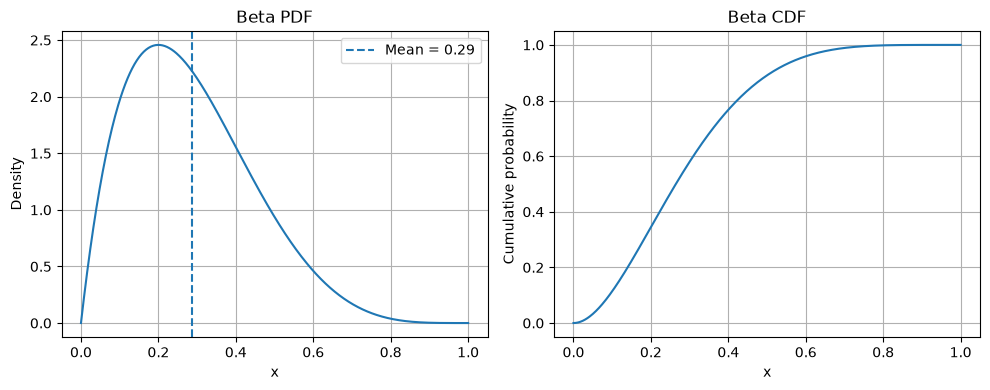

In [3]:
beta = Beta(alpha=2, beta=5)
print("Beta mean:", beta.mean())
print("Beta variance:", beta.variance())
beta.plot()